In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/house_price_prediction/01_dataset/houses.txt',
                 header = None,
                 names = ['size(sqft)' , 'bedrooms' , 'floor' , 'age' , 'price']
                 )

print(df.shape)
print(df.dtypes)
print(df.columns)
print(df.head())

(100, 5)
size(sqft)    float64
bedrooms      float64
floor         float64
age           float64
price         float64
dtype: object
Index(['size(sqft)', 'bedrooms', 'floor', 'age', 'price'], dtype='object')
   size(sqft)  bedrooms  floor   age  price
0       952.0       2.0    1.0  65.0  271.5
1      1244.0       3.0    1.0  64.0  300.0
2      1947.0       3.0    2.0  17.0  509.8
3      1725.0       3.0    2.0  42.0  394.0
4      1959.0       3.0    2.0  15.0  540.0


In [4]:
x_train = df.iloc[: , :4]

y_train = df.iloc[: , 4]


print(x_train.shape)
print(y_train.shape)

print(x_train.head())
print(y_train.head())

(100, 4)
(100,)
   size(sqft)  bedrooms  floor   age
0       952.0       2.0    1.0  65.0
1      1244.0       3.0    1.0  64.0
2      1947.0       3.0    2.0  17.0
3      1725.0       3.0    2.0  42.0
4      1959.0       3.0    2.0  15.0
0    271.5
1    300.0
2    509.8
3    394.0
4    540.0
Name: price, dtype: float64


In [5]:
y1 = df.iloc[: , 4]
print(y1[:10])
print(type(y1))

0    271.5
1    300.0
2    509.8
3    394.0
4    540.0
5    415.0
6    230.0
7    560.0
8    294.0
9    718.2
Name: price, dtype: float64
<class 'pandas.core.series.Series'>


In [6]:
y2 = df.iloc[: , 4:]
print(y2[:10])

print(type(y2))


# when using .iloc[:, 4] , its a series
# when .iloc[: , 4:] , when its a range, it gives dataframe.

   price
0  271.5
1  300.0
2  509.8
3  394.0
4  540.0
5  415.0
6  230.0
7  560.0
8  294.0
9  718.2
<class 'pandas.core.frame.DataFrame'>


In [7]:
# Our features have different range of values so we need to rescale the featues.
scaler = StandardScaler()
print(scaler)
print(type(scaler))

StandardScaler()
<class 'sklearn.preprocessing._data.StandardScaler'>


In [8]:
X_norm = scaler.fit_transform(x_train)
print(X_norm[:10])
print(X_norm.shape)

[[-1.12018542 -1.08793896 -0.78288136  1.02191098]
 [-0.41174475  0.44436943 -0.78288136  0.98312878]
 [ 1.29385043  0.44436943  1.27733275 -0.83963464]
 [ 0.75524143  0.44436943  1.27733275  0.12992037]
 [ 1.32296443  0.44436943  1.27733275 -0.91719904]
 [-0.24191308 -1.08793896 -0.78288136 -0.95598124]
 [-1.33368809 -1.08793896 -0.78288136  1.06069319]
 [ 1.02454593  0.44436943 -0.78288136 -0.83963464]
 [-0.94064908  0.44436943 -0.78288136  0.16870257]
 [ 4.31928028  1.97667783  1.27733275  1.8751194 ]]
(100, 4)


In [9]:
print(scaler.mean_)
print(scaler.scale_)

[1.41371e+03 2.71000e+00 1.38000e+00 3.86500e+01]
[412.17283499   0.65261014   0.48538644  25.78502472]


In [10]:
print(f"Peak to peak range by column in raw data: {np.ptp(x_train, axis = 0)}")
print(f"Peak to peak column range for normalized data: {np.ptp(X_norm, axis = 0)}")

Peak to peak range by column in raw data: size(sqft)    2406.0
bedrooms         4.0
floor            1.0
age             95.0
dtype: float64
Peak to peak column range for normalized data: [5.83735704 6.12923357 2.06021411 3.68430905]


In [13]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm , y_train)
print(sgdr)
print(f"Number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")


# sgdr.n_iter_ : tells how many iterations thee optimizer actually completed
# gdr.t_ : tells number of weight updates performed during training

SGDRegressor()
Number of iterations completed: 136, number of weight updates: 13601.0


In [14]:
print(sgdr.coef_)       # weights
print(sgdr.intercept_)  # bias

[110.30252569 -21.34190681 -32.49166766 -37.83584505]
[362.22869522]


In [16]:
w_norm = sgdr.coef_
b_norm = sgdr.intercept_

print(w_norm)
print(b_norm)

[110.30252569 -21.34190681 -32.49166766 -37.83584505]
[362.22869522]


In [17]:
y_predict_sgd = sgdr.predict(X_norm)
print(y_predict_sgd)

[248.66036143 295.56813123 485.72558962 389.63172289 491.87165204
 420.37124256 223.64312056 522.96041502 268.04315096 684.0207478
 182.76158215 318.52157477 479.53160528 409.90774398 393.74832782
 287.59344256 323.96421565 406.00418272 436.35562828 270.32236601
 500.55270302 329.0763559  388.20408429 551.63569968 242.27374904
 295.84776916 283.11920433 217.78616082 490.82889591 229.68394472
 341.49157374 291.76743417 489.85102852 239.16400393 597.66315147
 383.99400957 452.68900015 401.34051436 405.98614116 173.30130778
 423.55534117 434.14902345 277.34023997 229.68394472 448.42587548
 488.79862083 332.28105693 465.55306351 222.53658818 386.76378931
 456.44522409 370.60181227 468.81809198 310.52134247 426.48103505
 392.00433739 347.80301505 339.51004446 471.32025941 243.90091328
 298.57994706 273.34728848 250.41637746 298.20215529 335.17475355
 376.05866601 289.27473149 229.68394472 620.1696481  352.9484204
 510.7879344  364.05263902 363.28844607 298.20215529 407.24064163
 288.9620152

In [21]:
y_predict = np.dot(X_norm , w_norm) + b_norm
print(y_predict)

[248.66036143 295.56813123 485.72558962 389.63172289 491.87165204
 420.37124256 223.64312056 522.96041502 268.04315096 684.0207478
 182.76158215 318.52157477 479.53160528 409.90774398 393.74832782
 287.59344256 323.96421565 406.00418272 436.35562828 270.32236601
 500.55270302 329.0763559  388.20408429 551.63569968 242.27374904
 295.84776916 283.11920433 217.78616082 490.82889591 229.68394472
 341.49157374 291.76743417 489.85102852 239.16400393 597.66315147
 383.99400957 452.68900015 401.34051436 405.98614116 173.30130778
 423.55534117 434.14902345 277.34023997 229.68394472 448.42587548
 488.79862083 332.28105693 465.55306351 222.53658818 386.76378931
 456.44522409 370.60181227 468.81809198 310.52134247 426.48103505
 392.00433739 347.80301505 339.51004446 471.32025941 243.90091328
 298.57994706 273.34728848 250.41637746 298.20215529 335.17475355
 376.05866601 289.27473149 229.68394472 620.1696481  352.9484204
 510.7879344  364.05263902 363.28844607 298.20215529 407.24064163
 288.9620152

In [24]:
print(f"Prediction on training set: {y_predict[:5]}")
print(f"Actual training set: {y_train[:5]}")

Prediction on training set: [248.66036143 295.56813123 485.72558962 389.63172289 491.87165204]
Actual training set: 0    271.5
1    300.0
2    509.8
3    394.0
4    540.0
Name: price, dtype: float64


In [23]:
# comparing both predictions
print(f"Prediction using np.dot() and sgdr.predict(x_norm) is: {(y_predict == y_predict_sgd).all()}")

Prediction using np.dot() and sgdr.predict(x_norm) is: True


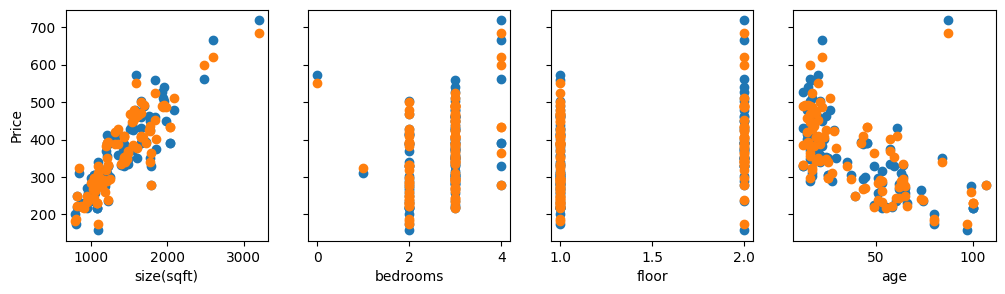

In [38]:
fig, ax = plt.subplots(1,4, figsize=(12,3) , sharey = True)
for i in range(len(ax)):
  # ax[i].scatter(x_train[:,i],y_train, label = 'target')
  ax[i].scatter(x_train.iloc[: , i], y_train , label = "Target")
  ax[i].scatter(x_train.iloc[: , i], y_predict, label = "Predicted")
  ax[i].set_xlabel(x_train.columns[i])
ax[0].set_ylabel("Price")
plt.show()